<a href="https://colab.research.google.com/github/sujalarora19/AI_Generated_Text_Detection/blob/main/test1_xai_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install transformers timm torch torchvision captum matplotlib


Vision Transformer (ViT) model pre-trained on ***ImageNet-21k*** (14 million images, 21,843 classes) at resolution 224x224, and fine-tuned on ***ImageNet 2012*** (1 million images, 1,000 classes) at resolution 224x224. It was introduced in the paper ***An Image is Worth 16x16 Words***: Transformers for Image Recognition at Scale by Dosovitskiy et al. and first released in [this repository](https://github.com/google-research/vision_transformer). However, the weights were converted from the [timm repository](https://github.com/huggingface/pytorch-image-models) by Ross Wightman, who already converted the weights from JAX to PyTorch

In [ ]:
from transformers import ViTFeatureExtractor, ViTForImageClassification
from PIL import Image
import torch
import torchvision.transforms as T
import requestsd

# Load model and feature extractor
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
model.eval()

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")





/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [ ]:
image = Image.open('new3.png').convert('RGB')

# Preprocess image
inputs = feature_extractor(images=image, return_tensors="pt")

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions  # List of attention maps for each layer

# Get prediction
pred_class = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[pred_class])


Predicted class: beach wagon, station wagon, wagon, estate car, beach waggon, station waggon, waggon


In [ ]:
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    logits = outputs.logits
    attentions = outputs.attentions  # Now this won't be None
  # List of attention maps for each layer

# Get prediction
pred_class = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[pred_class])


Predicted class: golden retriever


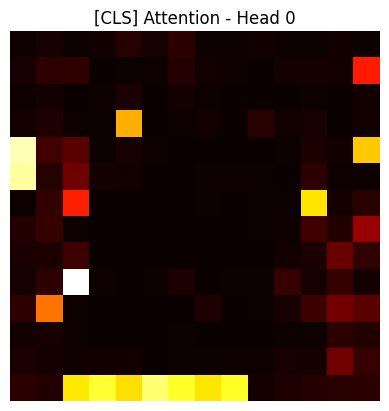

In [ ]:
import matplotlib.pyplot as plt
def show_attention_map(attn_map, head=0):
    """
    Show attention from the [CLS] token to the image patches for a given head.
    """
    # Get attention from CLS token to all other tokens
    cls_attn = attn_map[head, 0, 1:]  # (num_patches)

    num_patches = cls_attn.shape[0]
    size = int(num_patches ** 0.5)  # Assume square grid

    cls_attn = cls_attn.reshape(size, size).detach().cpu().numpy()

    plt.imshow(cls_attn, cmap='hot')
    plt.title(f"[CLS] Attention - Head {head}")
    plt.axis("off")
    plt.show()

# Use last layer’s attention
last_layer_attn = attentions[-1][0]  # (num_heads, num_tokens, num_tokens)

# Show attention from head 0
show_attention_map(last_layer_attn, head=0)


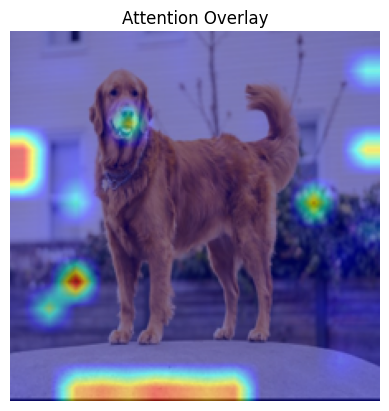

In [ ]:
import cv2
import numpy as np
from torchvision.transforms import Resize

def overlay_attention_on_image(image, attn_map, alpha=0.5):
    # Resize attention to match image size
    image = image.resize((224, 224))
    attn_map_resized = Resize((224, 224))(Image.fromarray((attn_map * 255).astype(np.uint8)))

    # Convert to numpy
    heatmap = np.array(attn_map_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    image_np = np.array(image)
    overlay = cv2.addWeighted(image_np, 1 - alpha, heatmap, alpha, 0)

    plt.imshow(overlay)
    plt.title("Attention Overlay")
    plt.axis("off")
    plt.show()

# Call it like this:
cls_attn = last_layer_attn[0, 0, 1:].reshape(14, 14).cpu().numpy()

# Normalize attention to [0, 1]
cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)

overlay_attention_on_image(image, cls_attn)


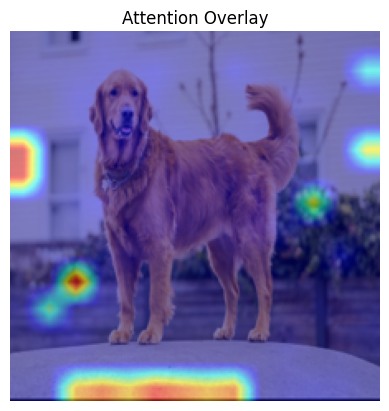

In [ ]:
mean_cls_attn = last_layer_attn[:, 0, 1:].mean(dim=0)  # (num_patches,)
mean_cls_attn = mean_cls_attn.reshape(14, 14).cpu().numpy()
# cls_attn = last_layer_attn[0, 0, 1:].reshape(14, 14).cpu().numpy()

# Normalize attention to [0, 1]
cls_attn = mean_cls_attn
cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)

overlay_attention_on_image(image, cls_attn)
